#### Université Paul Sabatier  2025-2026, Licence de Mathématiques, Math3-Num3
# Simulations stochastiques - TP6

In [1]:
%matplotlib inline
from matplotlib.pyplot import *
from math import *
from numpy import *
from numpy.random import *
from scipy.misc import *
from scipy.stats import *

## Fonction de répartition empirique et variable de test de Kolmogorov

Soit $X_1,\ldots,X_n$ des v.a. réelles i.i.d. de fonction de répartition $F$ continue. On note $X_{(1)} \leq \ldots \leq X_{(n)}$ la version ordonnée de ces variables et $D_n = D_n (F)$, où plus généralement
$$D_n (G) = \max_{1 \leq i \leq n} \max \left\{ \frac{i}{n} - G(X_{(i)}), \, G(X_{(i)}) - \frac{i-1}{n}\right\}$$
si $G$ est la fonction de répartition d'une loi sur $\mathbb{R}$.

Ecrire une fonction `Dn(X,G)` renvoyant la valeur de $D_n(G)$. Les arguments sont la fonction de répartition $G$, à spécifier ultérieurement, et $X$ (un `array` de taille $n$ contenant les réalisations des $X_i$).

In [2]:
def Dn(X,G):
    n = len(X)
    Y = sort(X)
    Z= [max(i/float(n)-G(Y[i-1]),G(Y[i-1])-(i-1)/float(n)) for i in range(1,n+1)]
    return max(Z) # attention aux indices !


Ecrire une fonction `plotFn(X,a,b,col='b')` qui trace (en bleu), sur l'intervalle $[a,b]$, la fonction de répartition empirique associée à la réalisation de l'échantillon spécifiée par $X$ (on suppose ici pour plus de commodité que les $X_i$ sont à valeurs dans l'intervalle compact $[a,b]$). (Indication : dernier code de la Q2 du TP1 à adapter pour avoir un tracé constant par morceaux).

In [3]:
def plotFn(X,a,b,col='b'):
    # On suppose les X_i à valeurs dans [a,b]
    n = len(X)
    Y = sort(X)
    plot([a,Y[0]],[0,0],col)
    for i in range(1,n):
        plot([Y[i-1],Y[i]],[i/float(n),i/float(n)],col) # attention aux indices !
    plot([Y[n-1],b],[1,1],col)

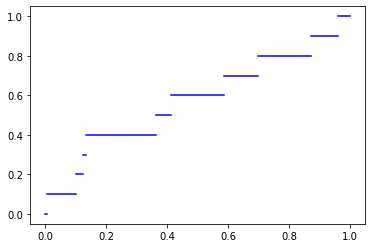

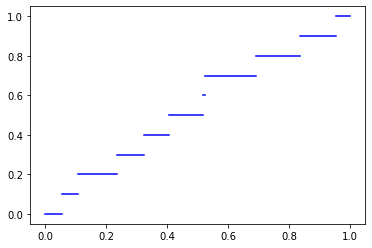

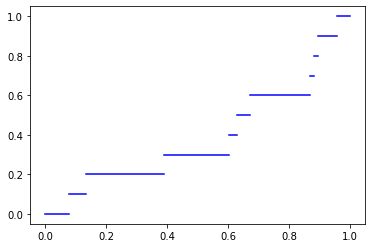

In [4]:
#### A tester avec
nn=10
for i in range(3):
    X=rand(nn)
    plotFn(X,0,1)
    show()

Pour un échantillon de taille $n = 20$ tiré selon la loi uniforme sur $[0,1]$, représentez graphiquement $F$ ainsi que la fonction de répartition empirique $F_n$. Vérifiez sur quelques simulations que $D_n = \sup_{x \in \mathbb{R}} |F_n(x) - F(x)|$.

In [6]:
def Funif(t):     #### Fonction de répartition d'une uniforme sur [0,1]
    return min(t,1)*(t>0)

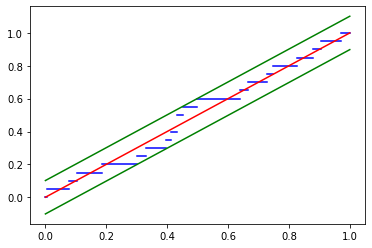

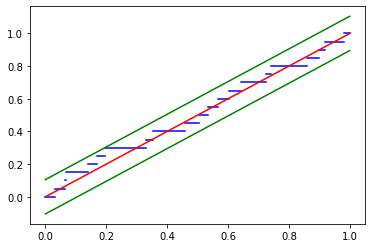

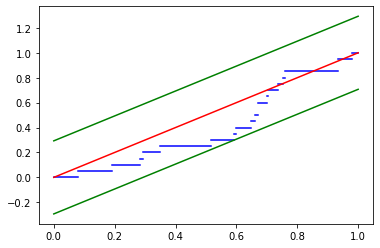

In [7]:

n = 20
for i in range(3):
    X = rand(n)
    plotFn(X,0,1)
    xx = linspace(0,1,101)
    plot(xx,xx,'r')
    dn = Dn(X,Funif)
    plot(xx,xx+dn,'g')
    plot(xx,xx-dn,'g')
    show()

Toujours en considérant la loi uniforme sur $[0,1]$, comment illustrer le fait que $\sup_{x \in \mathbb{R}} |F_n(x) - F(x)|$ tend presque sûrement vers $0$ lorsque $n \to +\infty$ ?

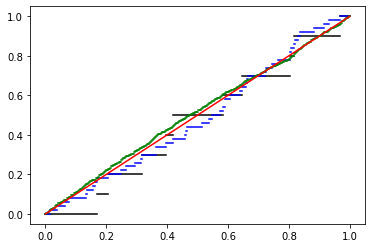

In [8]:
nn = [(10,'k'),(50,'b'),(1000,'g')]
X = rand(1000)
for n,col in nn:
    plotFn(X[0:n],0,1,col)
xx = linspace(0,1,101)
plot(xx,xx,'r')

Vérifiez numériquement que la loi de $D_n$ est la même quand les $X_i$ sont de loi uniforme $\text{Unif}([0,1])$ ou de loi exponentielle $\text{Exp}(1)$. Quel résultat du cours cela illustre-t-il ?

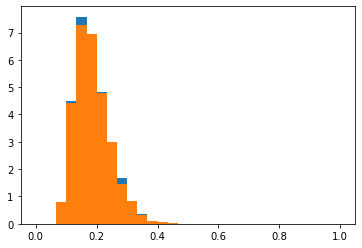

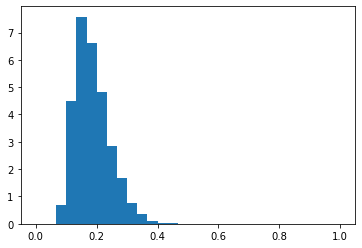

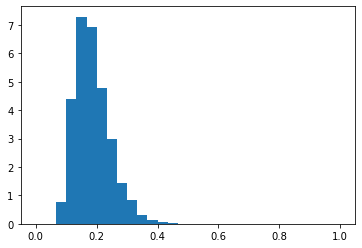

In [9]:
n = 20
Nsim = 10**4
Dn1 = zeros(Nsim)
Dn2 = zeros(Nsim)

def Fexp(t):
    return 1-exp(-t)

for sim in range(Nsim):
    Dn1[sim] = Dn(rand(n),Funif)
    Dn2[sim] = Dn(-log(rand(n)),Fexp)

hist(Dn1,bins=linspace(0,1,31),density=True)
hist(Dn2,bins=linspace(0,1,31),density=True)
show()


hist(Dn1,bins=linspace(0,1,31),density=True)
show()

hist(Dn2,bins=linspace(0,1,31),density=True)
show()
# Cela illustre le résultat du cours montrant que la loi de D_n est 
# la même pour toute f.d.r. F continue. C'est "le" (ou un) théorème de Kolmogorov.

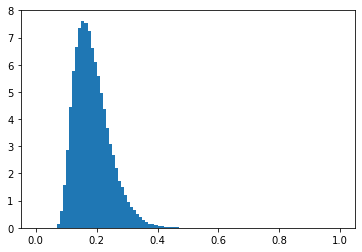

In [10]:
n = 20
Nsim = 10**5
Dn1 = zeros(Nsim)

for sim in range(Nsim):
    Dn1[sim] = Dn(rand(n),Funif)

hist(Dn1,bins=linspace(0,1,101),density=True)
show()



## Illustration du test de Kolmogorov

On peut évaluer numériquement le quantile d'ordre $0.98$ de la loi de $D_n(G)$, dans le cas où $G=F$ est la fonction de répartition (continue) des $X_i$. (Et ceci sans connaître a priori la loi exacte de $D_n(F)$). Pour $n=20$, le code suivant répond à la question. Comprenez-vous ce que fait ce code ?


In [15]:
n = 20
Nsim = 10**4
Dn1 = zeros(Nsim)
for sim in range(Nsim):
    Dn1[sim] = Dn(rand(n),Funif)
    
d = sort(Dn1)[int(ceil(0.98*Nsim))-1]
print('Quantile empirique d ordre 98% : ',d)



Quantile empirique d ordre 98% :  0.3284608999572186


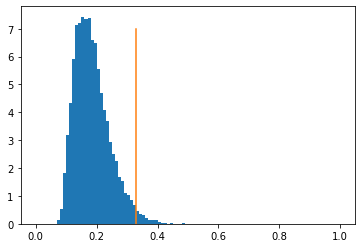

In [13]:
hist(Dn1,bins=linspace(0,1,101),density=True)
plot([d,d],[0,7])
show()

et le quantile $0.95$...

In [14]:
n = 20
Nsim = 10**4
Dn1 = zeros(Nsim)
for sim in range(Nsim):
    Dn1[sim] = Dn(rand(n),Funif)
    
q95 = sort(Dn1)[int(0.95*Nsim)]
print('Quantile empirique d ordre 95% : ',q95)

Quantile empirique d ordre 95% :  0.29239513786726073


En déduire un test (de niveau 2%) de l'hypothèse $H_0:F=F_{ref}$ contre 
l'hypothèse $H_1:F \neq F_{ref}$ valable pour toute fonction de répartition $F_{ref}$ continue. 





Indiquez ici le test $\Phi_n$ à considérer.

$$
\Phi_n = \mathbb{1}_{D_n(Fref) > d_{n,1-\alpha}}
$$

où $d_{n,1-\alpha}$ est le quantile théorique d'ordre $1-\alpha$ 
(qu'on remplace par le quantile empirique) de la loi de $D_n=D_n(F)$.


Vérifiez que le niveau effectif de ce test est bien de 2% en prenant comme loi de référence la loi exponentielle $\text{Exp}(2)$. 


In [12]:
def phiK(X,Fref):
    # Test de Kolmogorov de niveau environ 2%, pour Fref continue
    return Dn(X,Fref)>d

def Fexp2(t):
    return 1-exp(-2*t)

n = 20
EchantPhiH0=[phiK(-1./2*log(rand(n)),Fexp2) for sim in range(10**4)]
print('Vérification du niveau (risque de 1ère espèce) : ',mean(EchantPhiH0))

Vérification du niveau (risque de 1ère espèce) :  0.0229


Estimez le risque de seconde espèce lorsque 
l'échantillon provient de la loi normale de même espérance et même variance que $\text{Exp}(2)$.

In [13]:

EchantPhiH1=[phiK(0.5+0.5*randn(n),Fexp2) for sim in range(10**4)]

print('Estimation du risque de 2nde espèce pour N(1/2,1/4) : ',1-mean(EchantPhiH1))

Estimation du risque de 2nde espèce pour N(1/2,1/4) :  0.07179999999999997


Un peu plus : comparer la loi obtenue dans le dernier cas pour Dn(echantillon gaussien,Fexp2) à la loi attendue si echantillon adéquat.

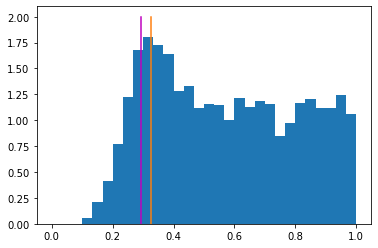

In [14]:
DnH1 = zeros(Nsim)
for sim in range(Nsim):
    DnH1[sim] = Dn(0.5+0.5*randn(n),Fexp2)
    
hist(DnH1,bins=linspace(0,1,31),density=True)
plot([d,d],[0,2]) #### test de risk 1ere espèce=niveau 2% en orange
plot([q95,q95],[0,2],'m') #### risk 1ere espèce=niveau 5% en magenta
show()    